In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [3]:
f = h5py.File("data/h2_results.hdf5", "r")
tebd_all_h = f["tebd_all_h"][:, :]
tebd_all_s = f["tebd_all_s"][:, :]
h_u = f["h_u"][:, :]
s_u = f["s_u"][:, :]
tebd_energies = f["tebd_energies"][:]
energies_u = f["energies_u"][:]
num_kept = f["num_kept"][:]
num_kept_u = f["num_kept_u"][:]
hf_energy = f["hf_energy"][()]
fci_energy = f["fci_energy"][()]
dmrg_energies = f["dmrg_energies"][()]
bond_sizes = f["bond_sizes"][()]
dmrg_bond_dims = f["dmrg_max_bond"][:]
tebd_bond_dims = f["tebd_max_bond"][:]
f.close()

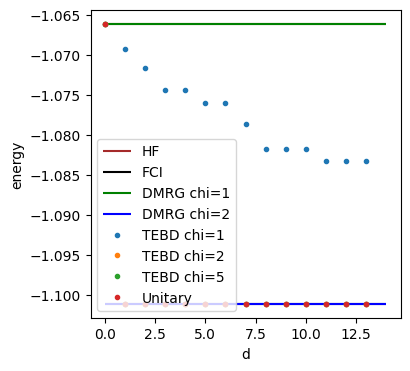

In [18]:
fig2, ax2 = plt.subplots(1, 1, figsize=(4, 4))
ax2.hlines(hf_energy, 0., tebd_energies.shape[1], colors=["brown"], label="HF")
ax2.hlines(fci_energy, 0., tebd_energies.shape[1], colors=["black"], label="FCI")
dmrg_colors = ["green", "blue"]
for i, (chi, dmrg_energy) in enumerate(zip(dmrg_bond_dims, dmrg_energies)):
    ax2.hlines(dmrg_energy, 0., tebd_energies.shape[1], dmrg_colors[i], label=f"DMRG chi={chi}")
for i, chi in enumerate(tebd_bond_dims):
    ax2.plot(tebd_energies[i, :], '.', label=f"TEBD chi={chi}")
ax2.plot(energies_u, '.', label="Unitary")
ax2.set_ylabel("energy")
ax2.set_xlabel("d")
ax2.legend(loc="lower left")